# EDA: 75K YouTube Comments — Pre-Labeling Analysis (v2)

**Project:** SpamShield — Deteksi Spam Promosi Judi Online pada Komentar YouTube Indonesia
**Author:** Ricky Rudiansyah (2702243016) · Co-author analyses: Elmer Williams
**Tahap:** Exploratory Data Analysis sebelum fase anotasi manual

---

### Tujuan

1. **Mendeskripsikan** karakteristik korpus mentah (ukuran, sumber, distribusi, temporal).
2. **Mengidentifikasi** pola empiris (obfuskasi, brand, repetisi, metadata) yang menjadi dasar empiris untuk rule-based annotation guideline.
3. **Menghasilkan** artefak reproducible (statistik + brand inventory + sample examples) untuk dikutip di bab Metodologi dan dimasukkan ke `annotation_guideline_v4.md`.

### Konvensi

- Notebook ini **defensive terhadap missing columns** — section akan di-skip dengan pesan jelas jika kolom yang dibutuhkan tidak ada.
- Kolom `_spam_signal` (jika ada) dipakai **hanya untuk eksplorasi** — annotator manual tidak melihat kolom ini.
- Numeric features yang sudah pre-computed (text_length, unicode_weird_ratio, dst.) di-reuse jika ada; di-compute on-the-fly jika belum.
- Semua key statistics di-collect ke `STATS` dict → di-export ke JSON di akhir.

## 0. Setup

Imports, plot theme, container statistik.

In [1]:
import re
import json
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

STATS = {}                       # collect untuk export di section akhir
RANDOM_STATE = 42

## 1. Data Loading & Schema Discovery

Load korpus, parse datetime, deteksi kolom yang available. Hasilnya: `COLS` dict yang dipakai sebagai gate di seluruh notebook — section akan di-skip kalau kolomnya nggak ada.

In [2]:
DATA_PATH = "./raw_75k.csv"      # ← sesuaikan dengan path kamu
df = pd.read_csv(DATA_PATH)

print(f"Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory        : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nColumns ({len(df.columns)}):")
for c in df.columns:
    print(f"  {c:32s}  {str(df[c].dtype):12s}  null={df[c].isna().sum():,}")
df.head(2)

Shape         : 75,532 rows × 24 columns
Memory        : 26.9 MB

Columns (24):
  comment_text                      str           null=12
  comment_published_at              str           null=0
  comment_updated_at                str           null=0
  author_display_name               str           null=0
  like_count                        int64         null=0
  reply_count                       int64         null=0
  channel_subscriber_count          int64         null=0
  channel_video_count               int64         null=0
  channel_view_count                int64         null=0
  channel_created_at                str           null=1
  channel_description_length        int64         null=0
  video_comment_count               int64         null=0
  text_length                       int64         null=0
  word_count                        int64         null=0
  emoji_ratio                       float64       null=0
  uppercase_ratio                   float64       null=0
  speci

,comment_text,comment_published_at,comment_updated_at,author_display_name,like_count,reply_count,channel_subscriber_count,channel_video_count,channel_view_count,channel_created_at,channel_description_length,video_comment_count,text_length,word_count,emoji_ratio,uppercase_ratio,special_char_ratio,repeat_char_ratio,unicode_weird_ratio,invisible_char_ratio,masked_keyword_ratio,stretched_word_ratio,slang_ratio,slang_distortion_ratio
0,Assalamualaikum bang tolong ijin nin pengguna ...,2025-05-16T06:33:09Z,2025-05-16T06:33:09Z,@Shiro-danji,0,0,1,1,567,2023-03-02T08:21:51.63267Z,216,95,200,33,0.000,0.010,0.010,0.000,0.000,0.005,0.000,0.000,0.182,0.000
1,re almeng Suramadu olanya itunya,2025-04-24T21:56:58Z,2025-04-24T21:56:58Z,@DaffaaPR,2,0,2,0,0,2020-07-27T09:10:36.078816Z,149,95,32,5,0.000,0.031,0.000,0.000,0.000,0.000,0.000,0.000,0.200,0.000


In [3]:
# Parse datetime jika ada
DT_COLS = ["comment_published_at", "comment_updated_at", "channel_created_at"]
for c in DT_COLS:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce", utc=True)

# Schema gate — sumber kebenaran untuk semua section di bawah
COLS = {
    "text":         "comment_text",
    "author":       "author_display_name" if "author_display_name" in df.columns else None,
    "channel":      "source_channel"      if "source_channel"      in df.columns else None,
    "video":        "video_id"            if "video_id"            in df.columns else None,
    "published":    "comment_published_at" if "comment_published_at" in df.columns else None,
    "channel_age":  "channel_age_days"    if "channel_age_days"    in df.columns else None,
    "subs":         "channel_subscriber_count" if "channel_subscriber_count" in df.columns else None,
    "vidcount":     "channel_video_count" if "channel_video_count" in df.columns else None,
    "likes":        "like_count"          if "like_count"          in df.columns else None,
    "replies":      "reply_count"         if "reply_count"         in df.columns else None,
    "spam_signal":  "_spam_signal"        if "_spam_signal"        in df.columns else None,
}

# Auto-detect kolom umur akun jika dihitung dari channel_created_at
if COLS["channel_age"] is None and "channel_created_at" in df.columns:
    df["channel_age_days"] = (
        (pd.Timestamp.utcnow() - df["channel_created_at"]).dt.days
    )
    COLS["channel_age"] = "channel_age_days"
    print("→ Computed channel_age_days from channel_created_at")

print("Available columns:")
for k, v in COLS.items():
    flag = "✓" if v else "✗"
    print(f"  {flag} {k:14s}  {v}")

→ Computed channel_age_days from channel_created_at
Available columns:
  ✓ text            comment_text
  ✓ author          author_display_name
  ✗ channel         None
  ✗ video           None
  ✓ published       comment_published_at
  ✓ channel_age     channel_age_days
  ✓ subs            channel_subscriber_count
  ✓ vidcount        channel_video_count
  ✓ likes           like_count
  ✓ replies         reply_count
  ✗ spam_signal     None


C:\Users\Ricky\AppData\Local\Temp\ipykernel_37924\2333024244.py:25: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  (pd.Timestamp.utcnow() - df["channel_created_at"]).dt.days


In [4]:
# Integrity check
print(f"Total rows                    : {len(df):,}")
print(f"Duplicate rows (full)         : {df.duplicated().sum():,}")
print(f"Duplicate comment_text        : {df.duplicated(subset='comment_text').sum():,}  "
      f"({df.duplicated(subset='comment_text').mean()*100:.2f}%)")
if "comment_id" in df.columns:
    print(f"Duplicate comment_id          : {df.duplicated(subset='comment_id').sum():,}")
print(f"Null comment_text             : {df['comment_text'].isna().sum():,}")

# Drop null text untuk safety
n_before = len(df)
df = df.dropna(subset=["comment_text"]).reset_index(drop=True)
if len(df) < n_before:
    print(f"\n→ Dropped {n_before - len(df):,} rows dengan null comment_text")

Total rows                    : 75,532
Duplicate rows (full)         : 9
Duplicate comment_text        : 6,767  (8.96%)
Null comment_text             : 12

→ Dropped 12 rows dengan null comment_text


## 2. Corpus-Level Statistics

Ukuran korpus, unique entities. Defensive — hanya kolom yang ada yang dilaporkan.

In [5]:
corpus = {"total_comments": int(len(df))}
if COLS["author"]:  corpus["unique_authors"]  = int(df[COLS["author"]].nunique())
if COLS["channel"]: corpus["unique_channels"] = int(df[COLS["channel"]].nunique())
if COLS["video"]:   corpus["unique_videos"]   = int(df[COLS["video"]].nunique())

STATS["corpus"] = corpus
pd.Series(corpus, name="value").to_frame()

,value
total_comments,75520
unique_authors,52952


In [6]:
# Distribusi per source channel — hanya jika kolom ada
if COLS["channel"]:
    chan_stats = (df.groupby(COLS["channel"])
                    .agg(n_comments=(COLS["text"], "count"),
                         n_authors=(COLS["author"], "nunique") if COLS["author"] else (COLS["text"], "count"))
                    .sort_values("n_comments", ascending=False))
    chan_stats["pct"] = (chan_stats["n_comments"] / len(df) * 100).round(2)

    fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * len(chan_stats))))
    chan_stats["n_comments"].iloc[::-1].plot(kind="barh", ax=ax,
                                              color=sns.color_palette("Set2")[0])
    ax.set(xlabel="Jumlah Komentar", ylabel="Source Channel",
           title="Distribusi Komentar per Source Channel")
    plt.tight_layout()
    plt.show()
    display(chan_stats)
else:
    print("✗ Kolom source_channel tidak tersedia — section ini di-skip.")
    print("  Alternatif: gunakan video_id sebagai proxy jika tersedia.")
    if COLS["video"]:
        vid_dist = df[COLS["video"]].value_counts()
        print(f"\n  Komentar tersebar di {vid_dist.shape[0]} video unik.")
        print(f"  Top-5 video by comment count:")
        display(vid_dist.head().to_frame("n_comments"))

✗ Kolom source_channel tidak tersedia — section ini di-skip.
  Alternatif: gunakan video_id sebagai proxy jika tersedia.


## 3. Temporal Analysis

Volume komentar per waktu. Spam dari coordinated campaigns biasanya datang dalam **bursts** — spike harian/mingguan yang jauh di atas baseline. Pattern ini menjadi salah satu signal awal untuk Rule R8 (Copy-Paste Pattern).

Date range: 2024-12-31 17:36:47+00:00  →  2026-02-09 12:34:09+00:00
Total days dengan komentar: 401


C:\Users\Ricky\AppData\Local\Temp\ipykernel_37924\4265064738.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = pub.dropna().dt.to_period("M").value_counts().sort_index()


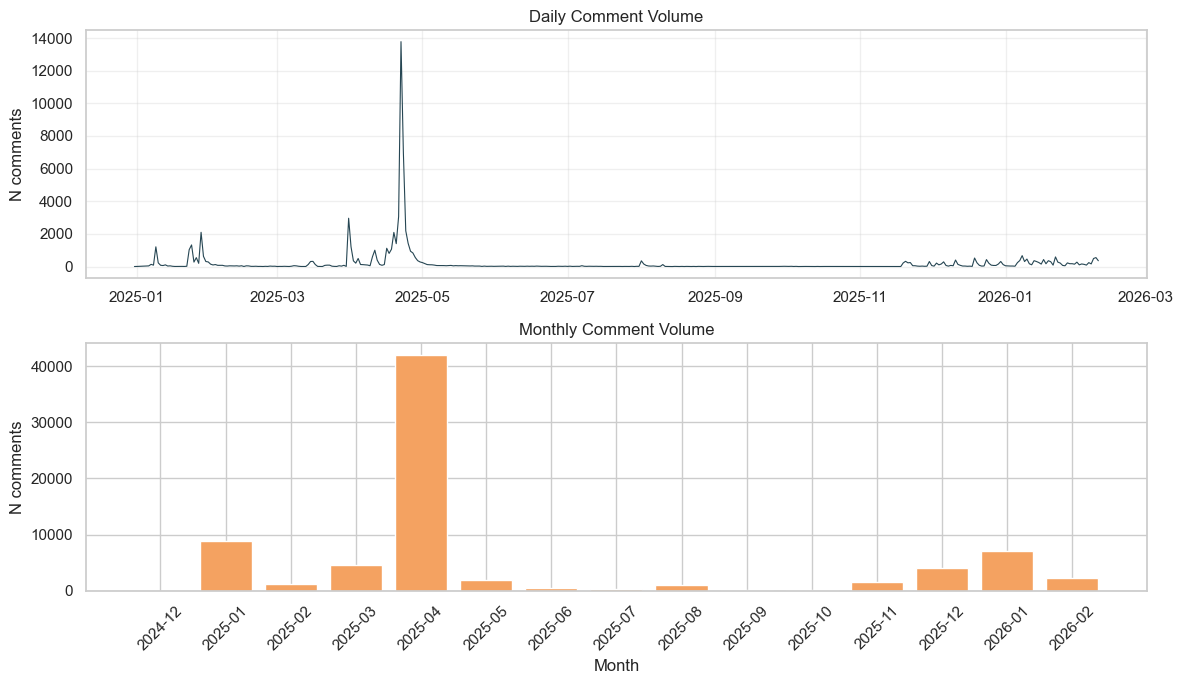


Peak day: 2025-04-22 dengan 13,777 komentar


In [7]:
if COLS["published"] and df[COLS["published"]].notna().any():
    pub = df[COLS["published"]]

    daily = pub.dropna().dt.tz_convert(None).dt.date.value_counts().sort_index()
    monthly = pub.dropna().dt.to_period("M").value_counts().sort_index()

    print(f"Date range: {pub.min()}  →  {pub.max()}")
    print(f"Total days dengan komentar: {len(daily)}")

    fig, axes = plt.subplots(2, 1, figsize=(12, 7))

    axes[0].plot(daily.index, daily.values, color="#264653", linewidth=0.8)
    axes[0].set(title="Daily Comment Volume", xlabel="", ylabel="N comments")
    axes[0].grid(alpha=0.3)

    monthly.index = monthly.index.astype(str)
    axes[1].bar(monthly.index, monthly.values, color="#F4A261")
    axes[1].set(title="Monthly Comment Volume", xlabel="Month", ylabel="N comments")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

    STATS["temporal"] = {
        "date_min": str(pub.min()),
        "date_max": str(pub.max()),
        "n_active_days": int(len(daily)),
        "peak_daily_count": int(daily.max()),
        "peak_daily_date": str(daily.idxmax()),
    }
    print(f"\nPeak day: {daily.idxmax()} dengan {daily.max():,} komentar")
else:
    print("✗ comment_published_at tidak tersedia — section ini di-skip.")

## 4. Text Characteristics

Surface-level features: panjang, jumlah kata, presence URL/mention/hashtag/emoji. Justifikasi untuk pilihan `max_length=128` saat tokenisasi IndoRoBERTa.

**Behavior**: jika fitur sudah pre-computed (dari `feature_extraction.ipynb`), reuse; jika belum, compute on-the-fly.

In [8]:
EMOJI_PATTERN = re.compile(
    "[" "\U0001F600-\U0001F64F" "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF" "\U0001F1E0-\U0001F1FF"
        "\U00002600-\U000027BF" "]+", flags=re.UNICODE)
URL_RE     = re.compile(r"https?://\S+|www\.\S+", re.I)
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#\w+")

def compute_surface(t):
    if pd.isna(t): return {"text_length": 0, "word_count": 0, "n_emoji": 0,
                           "has_url": 0, "has_mention": 0, "has_hashtag": 0}
    t = str(t)
    return {
        "text_length": len(t),
        "word_count":  len(re.findall(r"\b\w+\b", t)),
        "n_emoji":     len(EMOJI_PATTERN.findall(t)),
        "has_url":     int(bool(URL_RE.search(t))),
        "has_mention": int(bool(MENTION_RE.search(t))),
        "has_hashtag": int(bool(HASHTAG_RE.search(t))),
    }

# Reuse jika sudah ada, compute selektif kalau belum
needed = ["text_length", "word_count", "n_emoji", "has_url", "has_mention", "has_hashtag"]
missing = [c for c in needed if c not in df.columns]
if missing:
    print(f"Computing missing surface features: {missing}")
    surf = pd.DataFrame(df[COLS["text"]].apply(compute_surface).tolist())
    for c in missing:
        df[c] = surf[c]
else:
    print("✓ Semua surface features sudah ada — reuse dari precompute.")

df[["text_length", "word_count", "n_emoji"]].describe().round(2)

Computing missing surface features: ['n_emoji', 'has_url', 'has_mention', 'has_hashtag']


,text_length,word_count,n_emoji
count,75520.000,75520.000,75520.000
mean,81.180,13.210,0.390
std,138.790,20.950,0.830
min,1.000,0.000,0.000
25%,27.000,5.000,0.000
50%,50.000,8.000,0.000
75%,86.000,15.000,1.000
max,9880.000,1235.000,84.000


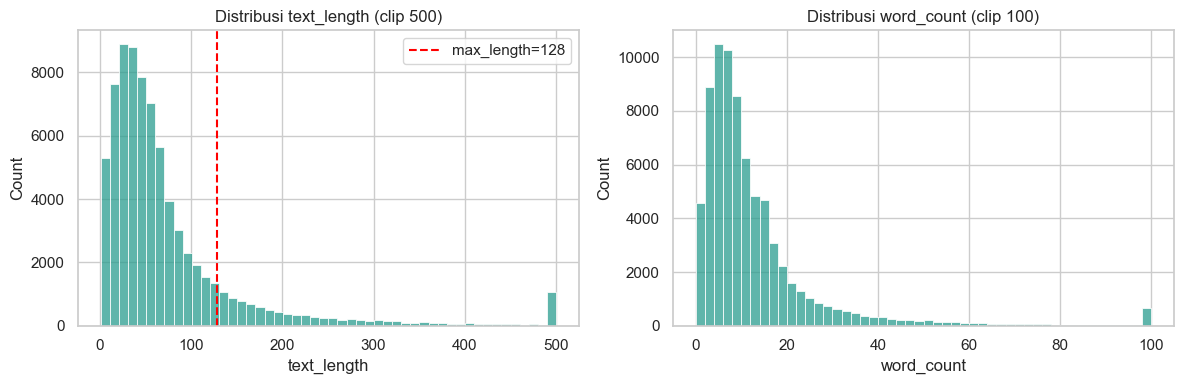

% komentar dengan text_length ≤ 512 chars (≈128 tokens): 98.70%


In [9]:
# Distribusi length
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["text_length"].clip(upper=500), bins=50, ax=axes[0], color="#2A9D8F")
axes[0].axvline(128, color="red", linestyle="--", label="max_length=128")
axes[0].set(title="Distribusi text_length (clip 500)", xlabel="text_length")
axes[0].legend()

sns.histplot(df["word_count"].clip(upper=100), bins=50, ax=axes[1], color="#2A9D8F")
axes[1].set(title="Distribusi word_count (clip 100)", xlabel="word_count")
plt.tight_layout()
plt.show()

# Coverage check untuk max_length=128 (assuming ~1 token / 4 chars untuk Indonesian)
pct_under_128 = (df["text_length"] <= 128 * 4).mean() * 100
print(f"% komentar dengan text_length ≤ 512 chars (≈128 tokens): {pct_under_128:.2f}%")
STATS["text_coverage_pct_under_512_chars"] = round(pct_under_128, 2)

In [10]:
# Presence features
presence = pd.DataFrame([
    {"feature": c, "count": int(df[c].sum()), "pct": round(df[c].mean() * 100, 2)}
    for c in ["has_url", "has_mention", "has_hashtag"]
])
STATS["text_presence_pct"] = presence.set_index("feature")["pct"].to_dict()
presence

,feature,count,pct
0,has_url,58,0.080
1,has_mention,5158,6.830
2,has_hashtag,168,0.220


## 5. Author Metadata Analysis

Distribusi fitur akun. Heavy right-skew → motivasi untuk `log1p` transform sebelum MLP fusion. Bucketing umur akun → relevant untuk Rule R9 (Suspicious Metadata).

,channel_age_days,channel_subscriber_count,channel_video_count,like_count
count,42304.000,75520.000,75520.000,75520.000
mean,1145.510,4063.140,26.630,6.100
std,688.330,203064.790,246.000,98.550
min,74.000,0.000,0.000,0.000
25%,477.000,0.000,0.000,0.000
50%,1029.000,2.000,0.000,0.000
75%,1795.000,13.000,5.000,1.000
max,2388.000,46000000.000,48561.000,9400.000


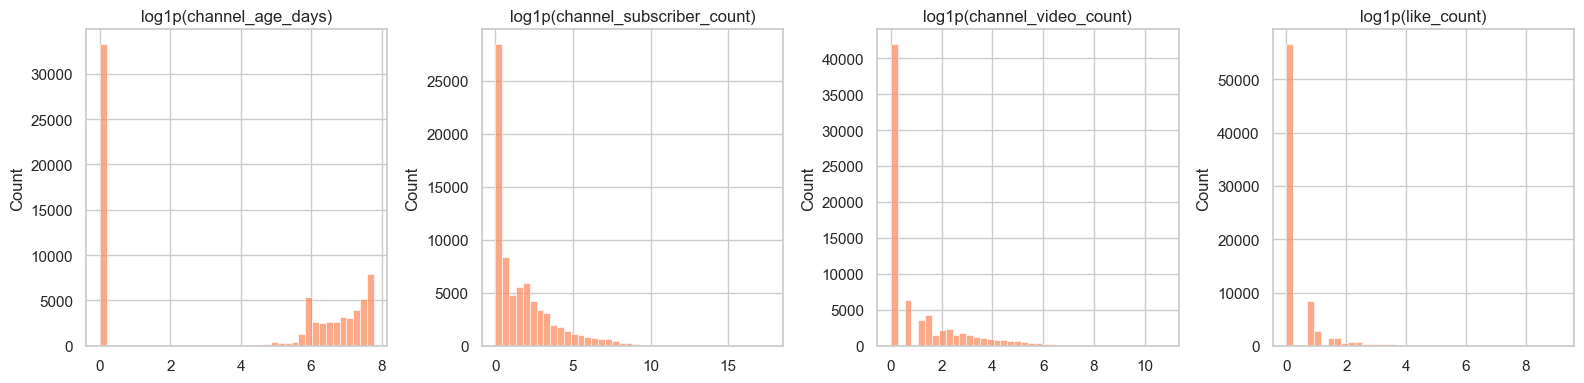

In [11]:
META_COLS = [v for v in [COLS["channel_age"], COLS["subs"], COLS["vidcount"], COLS["likes"]] if v]

if META_COLS:
    display(df[META_COLS].describe().round(2))

    # Log-scale histograms
    fig, axes = plt.subplots(1, len(META_COLS), figsize=(4 * len(META_COLS), 4))
    if len(META_COLS) == 1: axes = [axes]
    for ax, col in zip(axes, META_COLS):
        data = df[col].clip(lower=0).fillna(0)
        sns.histplot(np.log1p(data), bins=40, ax=ax, color=sns.color_palette("Set2")[1])
        ax.set(title=f"log1p({col})", xlabel="")
    plt.tight_layout()
    plt.show()
else:
    print("✗ Tidak ada kolom metadata — section ini di-skip.")

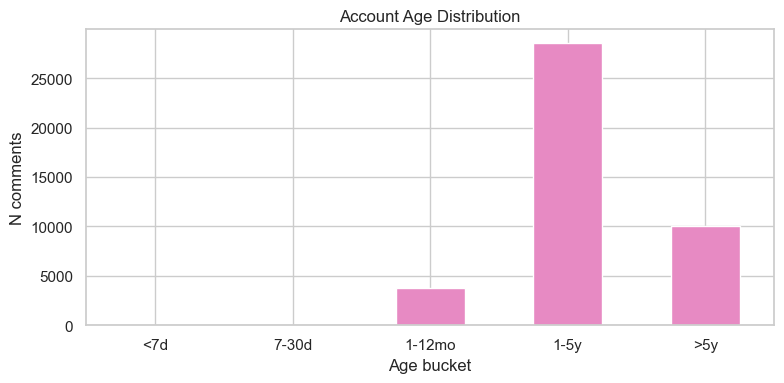

,count,pct
age_bucket,,
<7d,0,0.000
7-30d,0,0.000
1-12mo,3719,4.920
1-5y,28515,37.760
>5y,10070,13.330


In [12]:
# Bucketing umur akun
if COLS["channel_age"]:
    bins   = [-0.1, 7, 30, 365, 1825, np.inf]
    labels = ["<7d", "7-30d", "1-12mo", "1-5y", ">5y"]
    df["age_bucket"] = pd.cut(df[COLS["channel_age"]], bins=bins, labels=labels)

    age_dist = df["age_bucket"].value_counts().sort_index().to_frame("count")
    age_dist["pct"] = (age_dist["count"] / len(df) * 100).round(2)
    STATS["age_bucket_pct"] = age_dist["pct"].to_dict()

    fig, ax = plt.subplots(figsize=(8, 4))
    age_dist["count"].plot(kind="bar", ax=ax, color=sns.color_palette("Set2")[3])
    ax.set(title="Account Age Distribution", ylabel="N comments", xlabel="Age bucket")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    display(age_dist)
else:
    print("✗ channel_age_days tidak tersedia — bucketing di-skip.")

## 6. Author-Level Repetition Patterns

Top contributors. Komentar berulang dari author yang sama (terutama akun baru) adalah salah satu signal kuat untuk **bot farm**. Insight ini memotivasi Rule R9 di guideline.

Total author unik         : 52,952
Author dgn 1 komentar     : 42,333  (79.9%)
Author dgn ≥10 komentar   : 276
Author dgn ≥50 komentar   : 5


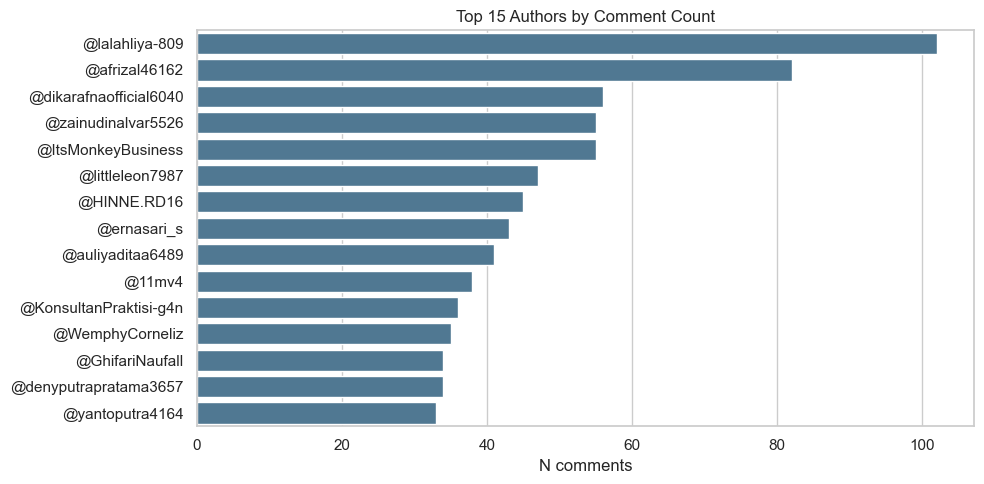

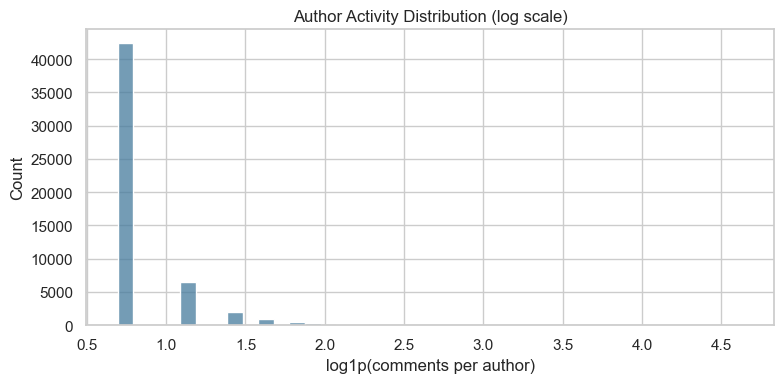

In [13]:
if COLS["author"]:
    author_counts = df[COLS["author"]].value_counts()

    print(f"Total author unik         : {author_counts.shape[0]:,}")
    print(f"Author dgn 1 komentar     : {(author_counts == 1).sum():,}  "
          f"({(author_counts == 1).mean() * 100:.1f}%)")
    print(f"Author dgn ≥10 komentar   : {(author_counts >= 10).sum():,}")
    print(f"Author dgn ≥50 komentar   : {(author_counts >= 50).sum():,}")

    STATS["author_repetition"] = {
        "total_authors":    int(author_counts.shape[0]),
        "single_comment_authors_pct": round((author_counts == 1).mean() * 100, 2),
        "authors_ge_10":    int((author_counts >= 10).sum()),
        "authors_ge_50":    int((author_counts >= 50).sum()),
    }

    # Top 15 authors
    top15 = author_counts.head(15)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=top15.values, y=top15.index, ax=ax, color="#457B9D")
    ax.set(title="Top 15 Authors by Comment Count",
           xlabel="N comments", ylabel="")
    plt.tight_layout()
    plt.show()

    # Distribusi log-scale
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(np.log1p(author_counts), bins=40, ax=ax, color="#457B9D")
    ax.set(title="Author Activity Distribution (log scale)",
           xlabel="log1p(comments per author)")
    plt.tight_layout()
    plt.show()
else:
    print("✗ author_display_name tidak tersedia — section ini di-skip.")

In [14]:
# Pattern bot farm: username dgn pola Nama+3digit (misal: BayuMaulana699)
if COLS["author"]:
    BOT_PATTERN = re.compile(r"^[A-Za-z]+\d{3}$")
    df["author_bot_pattern"] = df[COLS["author"]].fillna("").str.match(BOT_PATTERN).astype(int)

    n_bot = df["author_bot_pattern"].sum()
    print(f"Komentar dari author dgn pattern Nama+3digit: {n_bot:,}  "
          f"({n_bot / len(df) * 100:.2f}%)")
    STATS["bot_pattern_count"] = int(n_bot)

    # Sample examples (anonymized: hanya tampilkan pattern, bukan nama lengkap)
    if n_bot > 0:
        print("\nContoh username dengan pattern (top 5):")
        bot_authors = df.loc[df["author_bot_pattern"] == 1, COLS["author"]].value_counts().head(5)
        for name, cnt in bot_authors.items():
            masked = name[:3] + "***" + name[-3:] if len(name) > 6 else name
            print(f"  {masked:25s}  {cnt} komentar")

Komentar dari author dgn pattern Nama+3digit: 0  (0.00%)


## 7. Comment Text Repetition

Copy-paste spam — komentar identik dari banyak author berbeda. Ini adalah **signal terkuat untuk Rule R8** di guideline.

**Method**: identifikasi text yang muncul ≥5 kali dengan ≥3 author unik (untuk membedakan dari spam single-author yang spam reply ke video sendiri).

In [15]:
# Group by exact text (case-sensitive untuk preserve obfuscation pattern)
if COLS["author"]:
    text_groups = (df.groupby(COLS["text"])
                     .agg(n_occurrences=(COLS["text"], "count"),
                          n_unique_authors=(COLS["author"], "nunique"))
                     .sort_values("n_occurrences", ascending=False))
else:
    text_groups = (df[COLS["text"]].value_counts()
                     .to_frame("n_occurrences"))
    text_groups["n_unique_authors"] = 1

# Filter: copy-paste spam = banyak occurrences DAN banyak author unik
copypaste = text_groups[(text_groups["n_occurrences"] >= 5) &
                         (text_groups["n_unique_authors"] >= 3)]

print(f"Komentar dgn ≥5 occurrences & ≥3 unique authors: {len(copypaste):,} unique texts")
print(f"Total occurrences komentar copy-paste           : {copypaste['n_occurrences'].sum():,}")

STATS["copypaste"] = {
    "n_unique_texts": int(len(copypaste)),
    "total_occurrences": int(copypaste["n_occurrences"].sum()),
}

# Display top 10 (truncate text untuk readability)
preview = copypaste.head(10).copy()
preview.index = preview.index.map(lambda t: t[:80] + "..." if len(t) > 80 else t)
display(preview)

Komentar dgn ≥5 occurrences & ≥3 unique authors: 463 unique texts
Total occurrences komentar copy-paste           : 4,592


,n_occurrences,n_unique_authors
comment_text,,
Pertama,119,108
😂,52,50
❤,46,45
Bisa,45,44
😂😂😂,45,45
Aku,39,38
Up,35,31
pertama,33,32
👍,32,28


## 8. Numeric Feature Distributions (Elmer's pre-computed features)

Distribusi 12 numeric features yang sudah pre-computed di `feature_extraction.ipynb` (jika tersedia di dataset). Ini adalah fitur-fitur yang akan jadi input MLP branch di model fusion.

In [16]:
ELMER_FEATURES = [
    "text_length", "word_count", "emoji_ratio", "uppercase_ratio",
    "special_char_ratio", "repeat_char_ratio", "unicode_weird_ratio",
    "invisible_char_ratio", "masked_keyword_ratio", "stretched_word_ratio",
    "slang_ratio", "slang_distortion_ratio",
]
available_feats = [c for c in ELMER_FEATURES if c in df.columns]

print(f"Pre-computed features tersedia : {len(available_feats)} / {len(ELMER_FEATURES)}")
if available_feats:
    print(f"Available: {available_feats}")
    display(df[available_feats].describe().round(3).T)
else:
    print("✗ Tidak ada pre-computed features — run feature_extraction.ipynb dulu, atau skip section ini.")

Pre-computed features tersedia : 12 / 12
Available: ['text_length', 'word_count', 'emoji_ratio', 'uppercase_ratio', 'special_char_ratio', 'repeat_char_ratio', 'unicode_weird_ratio', 'invisible_char_ratio', 'masked_keyword_ratio', 'stretched_word_ratio', 'slang_ratio', 'slang_distortion_ratio']


,count,mean,std,min,25%,50%,75%,max
text_length,75520.000,81.182,138.789,1.000,27.000,50.000,86.000,9880.000
word_count,75520.000,13.206,20.949,0.000,5.000,8.000,15.000,1235.000
emoji_ratio,75520.000,0.008,0.016,0.000,0.000,0.000,0.010,0.485
uppercase_ratio,75520.000,0.059,0.115,0.000,0.010,0.029,0.050,1.000
special_char_ratio,75520.000,0.056,0.083,0.000,0.007,0.032,0.066,1.000
repeat_char_ratio,75520.000,0.005,0.015,0.000,0.000,0.000,0.000,0.208
unicode_weird_ratio,75520.000,0.030,0.073,0.000,0.000,0.000,0.029,1.000
invisible_char_ratio,75520.000,0.002,0.011,0.000,0.000,0.000,0.000,0.691
masked_keyword_ratio,75520.000,0.002,0.009,0.000,0.000,0.000,0.000,0.200
stretched_word_ratio,75520.000,0.002,0.010,0.000,0.000,0.000,0.000,0.182


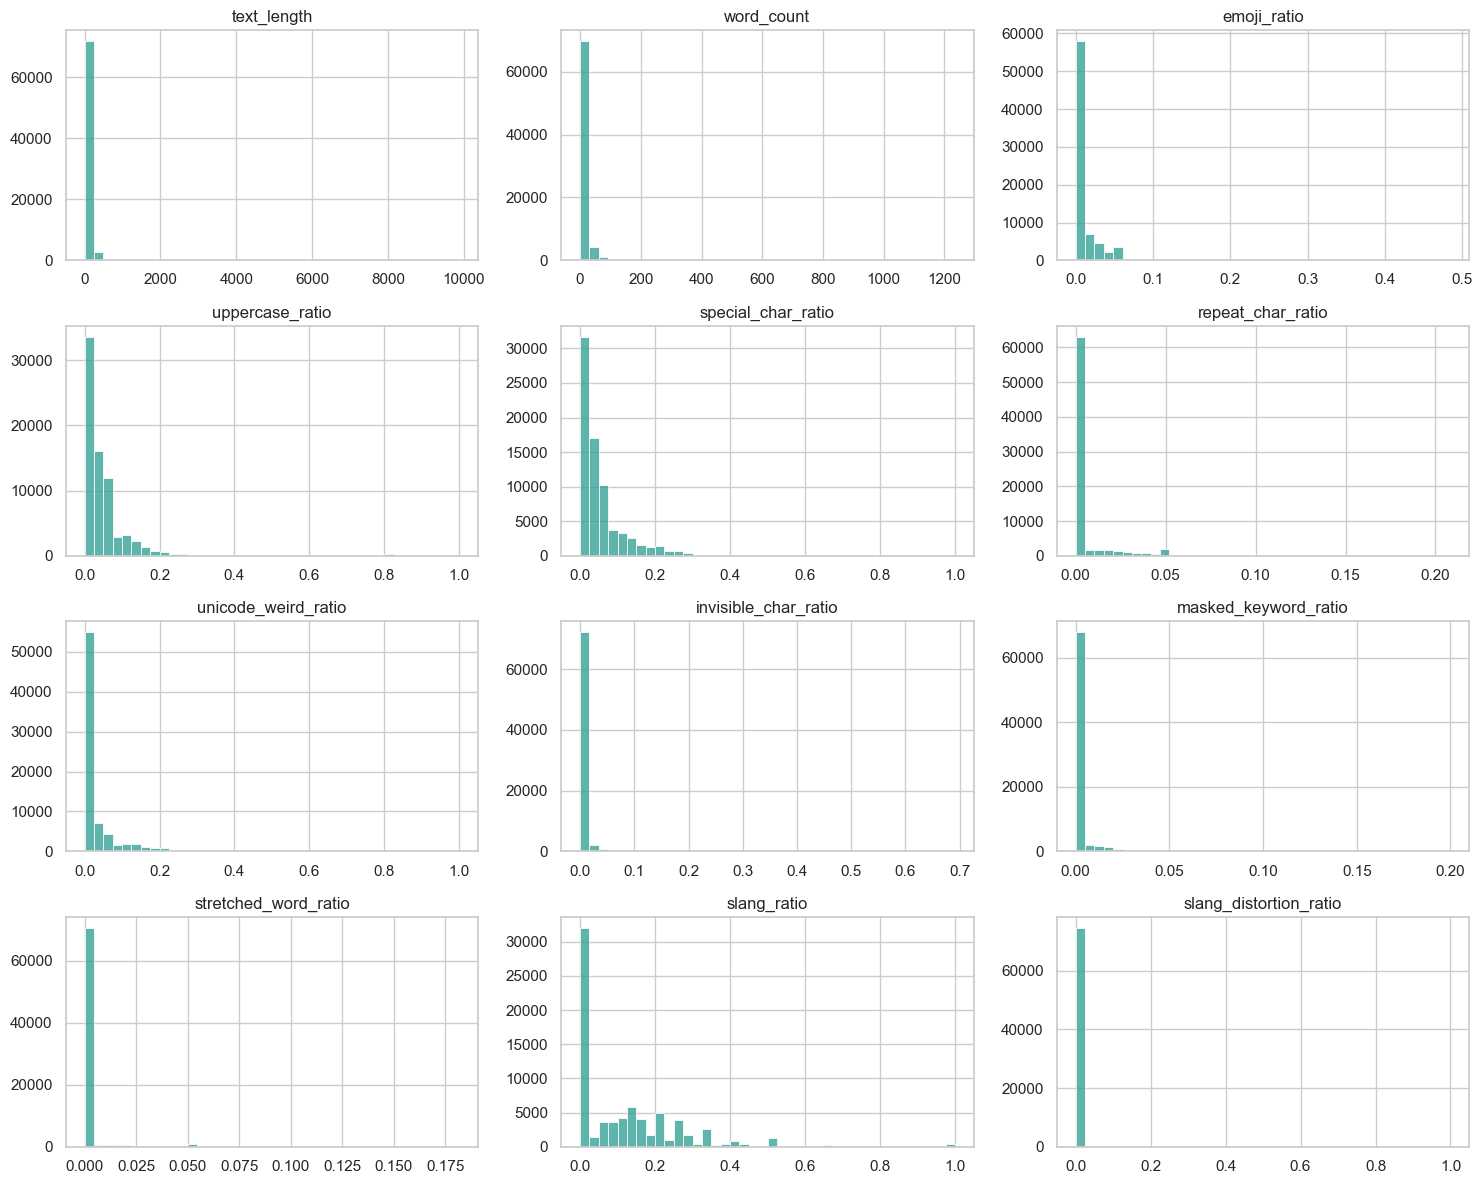

In [17]:
# Histogram grid
if available_feats:
    n_cols = 3
    n_rows = int(np.ceil(len(available_feats) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(available_feats):
        sns.histplot(df[col], bins=40, ax=axes[i], color="#2A9D8F", kde=False)
        axes[i].set(title=col, xlabel="", ylabel="")
    for j in range(len(available_feats), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

## 9. Correlation Analysis

Korelasi antar fitur numerik. Korelasi tinggi (|r| > 0.8) menandakan **redundansi** — kandidat untuk feature pruning sebelum training.

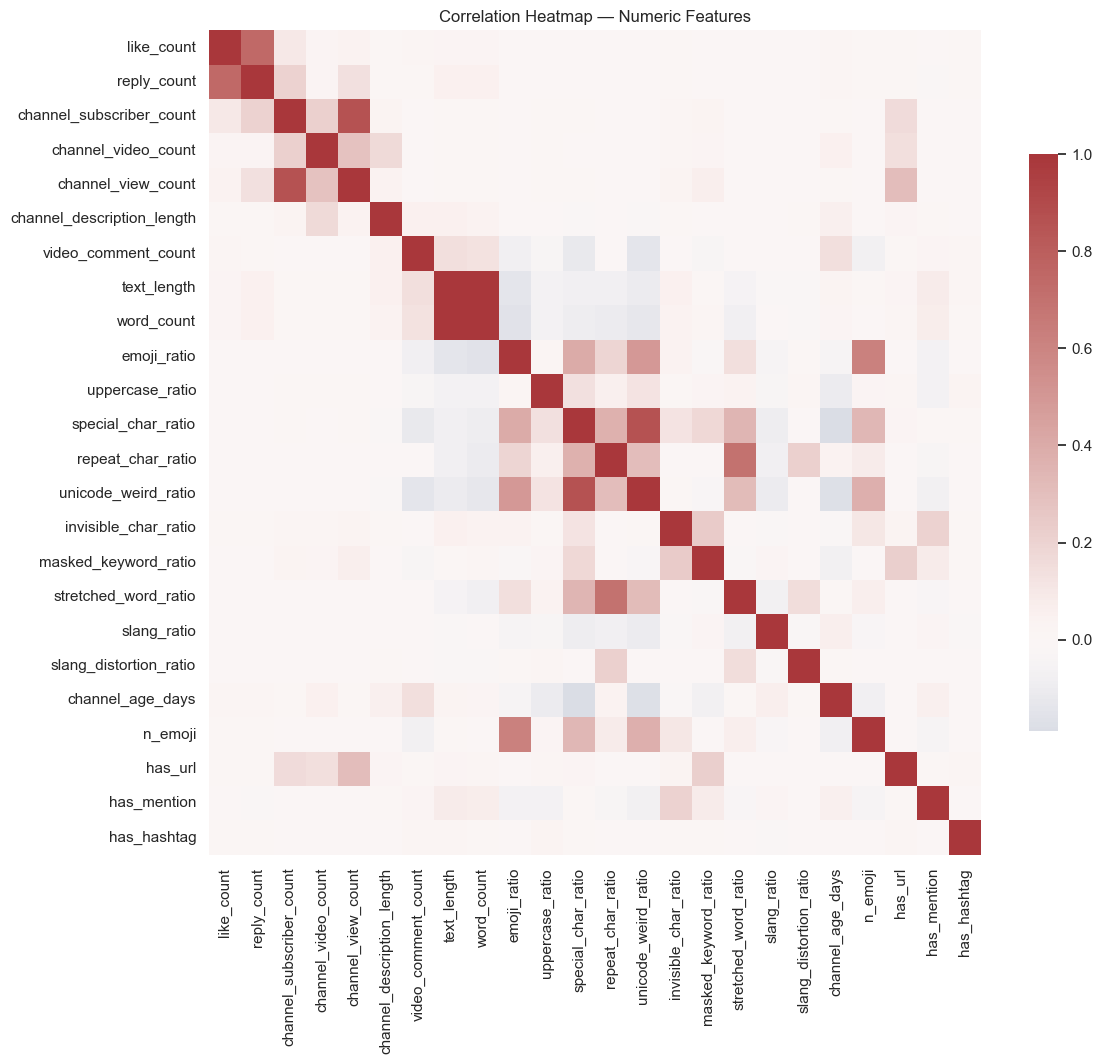


Pasangan dgn |r| > 0.7 (kandidat redundansi):


,feat_1,feat_2,r
2,text_length,word_count,0.992
1,channel_subscriber_count,channel_view_count,0.862
3,special_char_ratio,unicode_weird_ratio,0.862
0,like_count,reply_count,0.749


In [18]:
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in ["author_bot_pattern"]]

if len(numeric_cols) >= 3:
    corr = df[numeric_cols].corr(numeric_only=True)

    fig, ax = plt.subplots(figsize=(min(14, max(8, len(numeric_cols) * 0.5)),
                                     min(12, max(6, len(numeric_cols) * 0.45))))
    sns.heatmap(corr, cmap="vlag", center=0, square=False,
                cbar_kws={"shrink": 0.7}, ax=ax,
                xticklabels=True, yticklabels=True, annot=False)
    ax.set_title("Correlation Heatmap — Numeric Features")
    plt.tight_layout()
    plt.show()

    # Identifikasi pasangan yg sangat berkorelasi
    pairs = []
    for i, c1 in enumerate(corr.columns):
        for c2 in corr.columns[i+1:]:
            r = corr.loc[c1, c2]
            if abs(r) > 0.7:
                pairs.append({"feat_1": c1, "feat_2": c2, "r": round(r, 3)})

    if pairs:
        print(f"\nPasangan dgn |r| > 0.7 (kandidat redundansi):")
        display(pd.DataFrame(pairs).sort_values("r", key=abs, ascending=False))
    else:
        print("\nTidak ada pasangan dengan |r| > 0.7 — fitur cukup independen.")

## 10. Heuristic Spam Signal (Exploratory Only)

Kolom `_spam_signal` (jika ada) adalah flag biner hasil pre-filtering regex saat scraping. **Annotator manual tidak menggunakan kolom ini** — hanya untuk eksplorasi dan stratified sampling di IAA.

In [19]:
if COLS["spam_signal"]:
    rate = df[COLS["spam_signal"]].mean() * 100
    n_signal = int(df[COLS["spam_signal"]].sum())
    print(f"Heuristic signal rate : {rate:.2f}%  ({n_signal:,} komentar)")
    STATS["heuristic_signal_rate_pct"] = round(rate, 2)

    # Cross-tab dgn umur akun
    if "age_bucket" in df.columns:
        cross = (df.groupby("age_bucket", observed=True)[COLS["spam_signal"]]
                   .agg(n="count", rate="mean"))
        cross["rate_pct"] = (cross["rate"] * 100).round(2)
        display(cross[["n", "rate_pct"]])

        fig, ax = plt.subplots(figsize=(8, 4))
        cross["rate_pct"].plot(kind="bar", ax=ax, color="#E76F51")
        ax.set(title="Heuristic Signal Rate per Account Age Bucket",
               ylabel="Signal rate (%)", xlabel="")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()
else:
    print("✗ _spam_signal tidak tersedia — section ini di-skip.")

✗ _spam_signal tidak tersedia — section ini di-skip.


## 11. Obfuscation Pattern Inventory

Katalogisasi 6 teknik obfuskasi berdasarkan Unicode block + regex pattern. Kategori ini menjadi **dasar empiris untuk Rule R2 (Unicode Obfuscation) dan R3 (Cyrillic Mixing)** di guideline.

| Technique | Block / Pattern | Contoh |
|-----------|----------------|--------|
| Mathematical alphanumerics | U+1D400–U+1D7FF | 𝐏𝐔𝐋𝐀𝐔𝟕𝟕𝟕 |
| Fullwidth Latin | U+FF21–U+FF5A | ＰＵＬＡＵ |
| Enclosed alphanumerics | U+2460–U+24FF | ⓟⓤⓛⓐⓤ |
| Cyrillic | U+0400–U+04FF | РULAU |
| Zero-width / BIDI | U+200B–U+206F | PU​LAU |
| Spaced Latin | regex | P U L A U |

In [20]:
OBF_PATTERNS = {
    "math_alpha": re.compile(r"[\U0001D400-\U0001D7FF]"),
    "fullwidth":  re.compile(r"[\uFF21-\uFF3A\uFF41-\uFF5A]"),
    "enclosed":   re.compile(r"[\u2460-\u24FF\u3248-\u324F]"),
    "cyrillic":   re.compile(r"[\u0400-\u04FF]"),
    "zwsp":       re.compile(r"[\u200B-\u200F\u202A-\u202E\u2060-\u206F]"),
    "spaced":     re.compile(r"(?:[A-Za-z]\s){3,}[A-Za-z]"),
}

def obf_flags(t):
    if pd.isna(t): return {k: 0 for k in OBF_PATTERNS}
    t = str(t)
    return {k: int(bool(pat.search(t))) for k, pat in OBF_PATTERNS.items()}

obf_df = pd.DataFrame(df[COLS["text"]].apply(obf_flags).tolist())
for c in OBF_PATTERNS:
    df[c] = obf_df[c]
OBF_COLS = list(OBF_PATTERNS.keys())

# Frekuensi
obf_summary = pd.DataFrame([
    {"technique": c, "count": int(df[c].sum()),
     "pct_of_corpus": round(df[c].mean() * 100, 2)}
    for c in OBF_COLS
]).sort_values("count", ascending=False)

STATS["obfuscation_counts"] = obf_summary.set_index("technique")["count"].to_dict()
display(obf_summary)

,technique,count,pct_of_corpus
0,math_alpha,5047,6.680
4,zwsp,3136,4.150
5,spaced,1447,1.920
1,fullwidth,518,0.690
3,cyrillic,338,0.450
2,enclosed,52,0.070


In [21]:
# Sample examples per teknik — KRITIS untuk guideline calibration
print("=" * 70)
print("SAMPLE COMMENTS PER OBFUSCATION TECHNIQUE")
print("(untuk dimasukkan sebagai contoh di annotation_guideline_v4.md)")
print("=" * 70)

for tech in OBF_COLS:
    matches = df[df[tech] == 1][COLS["text"]]
    if len(matches) == 0:
        print(f"\n[{tech}] — tidak ada match")
        continue
    samples = matches.sample(min(3, len(matches)), random_state=RANDOM_STATE)
    print(f"\n[{tech}] — {len(matches):,} komentar total")
    for i, s in enumerate(samples, 1):
        s_clean = str(s)[:120].replace("\n", " ")
        print(f"  {i}. {s_clean}")

SAMPLE COMMENTS PER OBFUSCATION TECHNIQUE
(untuk dimasukkan sebagai contoh di annotation_guideline_v4.md)

[math_alpha] — 5,047 komentar total
  1. ✈Mudah konek padahal main spin santai doang ketik di google 🔥 𝐓 𝐊 𝐏 𝟑𝟎𝟑 🔥
  2. Rejeki muncul pas santai ☀️ Ketik di google ♥️𝐉 𝐔 𝐍 𝐈 𝐎 𝐑 𝟖 𝟖🚀
  3. kesukaan ku memamng 𝐗𝐔𝐗𝐔𝟒𝐃

[fullwidth] — 518 komentar total
  1. Nungguin bini belanja lama bnget sampe bete, iseng iseng nyari WEB terus ketemu Ｍandalika77 langsung spin kakek zeus, bu
  2. ＰⓤＬＡＵ777, tempat kemenangan berlipat!
  3. itu si rijal doyan banget main di ＰＵＬＡＵＷＩＮ. sampe kebeli motor

[enclosed] — 52 komentar total
  1. Top banget ⓅⓊⓁⒶⓊ⑦⑦⑦, jepe tiada henti.
  2. ＰⓤＬＡＵ777, tempat kemenangan berlipat!
  3. ＰⓤＬＡＵ777, lebih dari sekadar permainan!

[cyrillic] — 338 komentar total
  1. Di 𝐀 Е 𝙍 𝙊 𝟴 𝟪 menyediakan modal usaha yang membantu saya mencapai impian beli rumah. 🦙
  2. masih kena raja 𝔹О𝐖Ø𝟕𝟳 auto bos meledak
  3. Sapu bersih semua hadiah dan bonus yang ada di D Е 𝑊 𝐴 D O 𝘙 𝘼,auto

In [22]:
# Lift analysis: P(spam_signal | obfuscation) vs baseline
if COLS["spam_signal"]:
    base_rate = df[COLS["spam_signal"]].mean() * 100
    rows = []
    for c in OBF_COLS:
        subset = df[df[c] == 1]
        if len(subset) == 0:
            rows.append({"technique": c, "n": 0, "signal_rate_pct": 0, "lift": 0})
            continue
        rate = subset[COLS["spam_signal"]].mean() * 100
        rows.append({
            "technique": c,
            "n": len(subset),
            "signal_rate_pct": round(rate, 2),
            "lift": round(rate / base_rate, 2) if base_rate > 0 else 0,
        })
    lift_df = pd.DataFrame(rows).sort_values("lift", ascending=False)
    print(f"Baseline signal rate: {base_rate:.2f}%")
    display(lift_df)

## 12. Brand Extraction

Ekstraksi kandidat brand judi online dengan pattern `[KATA]+[ANGKA]` (PULAU777, MIYA88). Pipeline:

1. **NFKC normalization** → 𝐏𝐔𝐋𝐀𝐔 → PULAU
2. **Spaced char collapse** → "P U L A U" → "PULAU"
3. **Regex** `\b[A-Z]{2,12}\d{2,4}\b`
4. **False positive filter** — IPHONE15, RTX5090, dll.

Output: seed list untuk **Rule R1 (Brand Mention)** di guideline.

In [23]:
def normalize_for_brand(t):
    if pd.isna(t): return ""
    t = unicodedata.normalize("NFKC", str(t))
    t_up = t.upper()
    t_up = re.sub(r"(?<=[A-Z0-9])\s+(?=[A-Z0-9])", "", t_up)
    return t_up

BRAND_RE = re.compile(r"\b([A-Z]{2,12}\d{2,4})\b")
BRAND_NOISE = {
    "IPHONE14", "IPHONE15", "IPHONE16", "MACOS14", "COVID19", "GPT4",
    "PS5", "RTX4090", "RTX5090", "WINDOWS10", "WINDOWS11",
    "HTTP200", "HTTP404", "HTTP500", "MP4", "MP3",
}

df["brands_found"] = df[COLS["text"]].apply(
    lambda t: BRAND_RE.findall(normalize_for_brand(t))
)

all_brands = [b for brands in df["brands_found"] for b in brands]
brand_freq = pd.Series(Counter(all_brands))
brand_freq = brand_freq[~brand_freq.index.isin(BRAND_NOISE)]
brand_freq = brand_freq[brand_freq >= 5].sort_values(ascending=False)

STATS["brand_inventory_size"] = int(len(brand_freq))
print(f"Brand kandidat (freq ≥5)         : {len(brand_freq)}")
print(f"Total brand mention occurrences  : {brand_freq.sum():,}")
print(f"Komentar dengan ≥1 brand mention : {(df['brands_found'].str.len() > 0).sum():,}")

display(brand_freq.head(30).to_frame("frequency"))

Brand kandidat (freq ≥5)         : 27
Total brand mention occurrences  : 2,985
Komentar dengan ≥1 brand mention : 3,721


,frequency
ALEXIS17,1272
JUNIOR88,416
BERKAH99,329
TKP303,310
MIYA88,227
MANTAP89,90
PSTOTO99,64
PULAU777,53
MANDALIKA77,51
APALAGIINI07,25


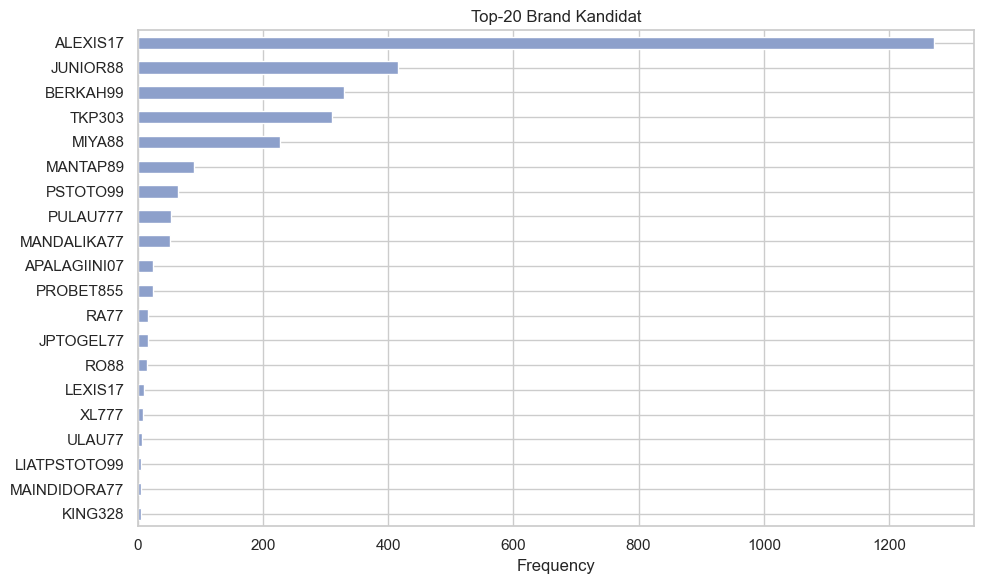

In [24]:
# Visualisasi top-20
top_n = min(20, len(brand_freq))
fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * top_n)))
brand_freq.head(top_n).iloc[::-1].plot(kind="barh", ax=ax,
                                         color=sns.color_palette("Set2")[2])
ax.set(xlabel="Frequency", title=f"Top-{top_n} Brand Kandidat")
plt.tight_layout()
plt.show()

In [25]:
# Sample komentar per brand (untuk guideline calibration)
print("=" * 70)
print("SAMPLE COMMENTS PER TOP-5 BRAND (untuk guideline)")
print("=" * 70)
for brand in brand_freq.head(5).index:
    matches = df[df["brands_found"].apply(lambda lst: brand in lst)][COLS["text"]]
    samples = matches.sample(min(2, len(matches)), random_state=RANDOM_STATE)
    print(f"\n[{brand}] — {len(matches):,} komentar")
    for i, s in enumerate(samples, 1):
        s_clean = str(s)[:140].replace("\n", " ")
        print(f"  {i}. {s_clean}")

SAMPLE COMMENTS PER TOP-5 BRAND (untuk guideline)

[ALEXIS17] — 1,268 komentar
  1. Keren parah! 🔥𝐀𝐋𝐄𝐗𝐈𝐒 𝟏𝟕🔥, penjelasan yang jelas dan vibe yang asik bikin video ini layak jadi top. Sukses selalu!
  2. Nggak bohong, ⭐ A L E X I S 1 7 ⭐ memang rekomendasi terbaik.

[JUNIOR88] — 416 komentar
  1. Mainnya terasa lebih aman karena alurnya jelas. Kenal 🚀 𝐉𝐔𝐍𝐈𝐎𝐑𝟖𝟖 💕 dari hasil pencarian.
  2. Langkah kecil hasil besar Ketik Di Google 🐉𝗝 𝗨 𝗡 𝗜 𝗢 𝗥 𝟴 𝟴🐉

[BERKAH99] — 329 komentar
  1. 08:16 Wajar kalo popularitas ✌𝗕𝗘𝗥𝗞𝗔𝗛𝟵𝟵 ✌ meledak, hasilnya nyata.
  2. 05:59 Sumpah keren parah! 𝗕𝗘𝗥𝗞𝗔𝗛𝟵𝟵

[TKP303] — 310 komentar
  1. Sawer tipis baliknya tebel Ketik di Google🔥𝐓 𝐊 𝐏 𝟑𝟎𝟑🔥
  2. Terrekomendasikan sekali 💜𝐓𝐊𝐏𝟑𝟎𝟑💜

[MIYA88] — 227 komentar
  1. Editing, ide, delivery — M I Y A 8 8 ⚜ angkat topi buat kamu!
  2. 🎉𝗠𝗜𝗬𝗔𝟴𝟴✨ tuh jawaban dari saldo yang terus kosong!


## 13. Pre-Labeling Stratification Preview

Preview komposisi IAA sample yang akan di-draw. Stratifikasi memastikan **semua kategori penting ter-represent** dalam 250 komentar IAA, bukan random sample yang bisa miss kategori langka.

In [26]:
# Bikin strata kombinasi: signal × ada_obfuskasi
df["any_obf"] = df[OBF_COLS].max(axis=1)

if COLS["spam_signal"]:
    df["stratum"] = (
        df[COLS["spam_signal"]].astype(str) + "_obf" + df["any_obf"].astype(str)
    )
else:
    df["stratum"] = "obf" + df["any_obf"].astype(str)

stratum_dist = df["stratum"].value_counts().to_frame("n")
stratum_dist["pct"] = (stratum_dist["n"] / len(df) * 100).round(2)
print("Distribusi strata:")
display(stratum_dist)

# Preview proportional sample untuk N=250
N_IAA = 250
print(f"\nProportional allocation untuk IAA N={N_IAA}:")
alloc = (stratum_dist["pct"] / 100 * N_IAA).round().astype(int)
display(alloc.to_frame("n_iaa"))

# Alternative: equal allocation (lebih balanced untuk rare strata)
print(f"\nEqual allocation untuk IAA N={N_IAA} ({N_IAA // len(stratum_dist)} per stratum):")
print(f"  → {N_IAA // len(stratum_dist)} komentar per stratum")
print(f"  Recommended: equal allocation untuk maximize coverage kasus rare.")

Distribusi strata:


,n,pct
stratum,,
obf0,65387,86.580
obf1,10133,13.420



Proportional allocation untuk IAA N=250:


,n_iaa
stratum,
obf0,216
obf1,34



Equal allocation untuk IAA N=250 (125 per stratum):
  → 125 komentar per stratum
  Recommended: equal allocation untuk maximize coverage kasus rare.


## 14. Summary & Export Artifacts

Tabel ringkasan + export ke file untuk dipakai di (a) bab Metodologi thesis, (b) finalisasi guideline v4.

In [27]:
def fmt(v):
    if isinstance(v, (int, np.integer)): return f"{v:,}"
    if isinstance(v, (float, np.floating)): return f"{v:.2f}"
    return str(v)

rows = [
    ("Total komentar",           len(df)),
    ("Unique authors",           df[COLS["author"]].nunique() if COLS["author"] else "N/A"),
    ("Unique source channels",   df[COLS["channel"]].nunique() if COLS["channel"] else "N/A"),
    ("Unique videos",            df[COLS["video"]].nunique() if COLS["video"] else "N/A"),
    ("Median text_length",       df["text_length"].median()),
    ("Median word_count",        df["word_count"].median()),
    ("Heuristic signal rate %",  round(df[COLS["spam_signal"]].mean()*100, 2) if COLS["spam_signal"] else "N/A"),
    ("Authors w/ ≥10 comments",  STATS.get("author_repetition", {}).get("authors_ge_10", "N/A")),
    ("Copy-paste unique texts",  STATS.get("copypaste", {}).get("n_unique_texts", "N/A")),
    ("Komentar Unicode math",    int(df["math_alpha"].sum())),
    ("Komentar spaced Latin",    int(df["spaced"].sum())),
    ("Komentar Cyrillic mixing", int(df["cyrillic"].sum())),
    ("Brand kandidat (freq ≥5)", STATS.get("brand_inventory_size", 0)),
]
summary = pd.DataFrame(rows, columns=["metric", "value"])
summary["value"] = summary["value"].apply(fmt)
display(summary)

,metric,value
0,Total komentar,"75,520"
1,Unique authors,"52,952"
2,Unique source channels,N/A
3,Unique videos,N/A
4,Median text_length,50.00
5,Median word_count,8.00
6,Heuristic signal rate %,N/A
7,Authors w/ ≥10 comments,276
8,Copy-paste unique texts,463
9,Komentar Unicode math,"5,047"


In [28]:
# Export
with open("eda_stats.json", "w", encoding="utf-8") as f:
    json.dump(STATS, f, indent=2, ensure_ascii=False, default=str)

brand_freq.to_frame("frequency").to_csv("brand_inventory.csv", encoding="utf-8")

# Parquet untuk analisis lanjutan (stratified IAA sampling)
try:
    df.to_parquet("df_75k_with_eda_features.parquet", index=False)
    parquet_ok = True
except Exception as e:
    df.to_csv("df_75k_with_eda_features.csv", index=False, encoding="utf-8")
    parquet_ok = False
    print(f"(Parquet tidak tersedia — fallback ke CSV. Reason: {e})")

print("Saved:")
print("  • eda_stats.json           — statistik kunci untuk dikutip di thesis")
print("  • brand_inventory.csv      — seed list untuk guideline Rule R1")
print(f"  • df_75k_with_eda_features.{'parquet' if parquet_ok else 'csv'}  "
      f"— basis untuk stratified IAA sampling")

Saved:
  • eda_stats.json           — statistik kunci untuk dikutip di thesis
  • brand_inventory.csv      — seed list untuk guideline Rule R1
  • df_75k_with_eda_features.parquet  — basis untuk stratified IAA sampling


---

## Outputs & Translasi ke Thesis

| Section | Output | Translasi ke Thesis |
|---------|--------|--------------------|
| §2 Corpus stats | unique authors/channels/videos | Bab 3.1 *Data Collection* |
| §3 Temporal | date range, peak day | Bab 3.1 *Data Characteristics* |
| §4 Text | text_length distribution | Justifikasi `max_length=128` IndoRoBERTa |
| §5 Metadata | log1p distribution, age bucketing | Justifikasi feature engineering |
| §6 Author repetition | bot pattern count | Empirical grounding Rule R9 |
| §7 Text repetition | copy-paste unique texts | Empirical grounding Rule R8 |
| §8 Numeric features | distribution Elmer's 12 features | Bab 4 *Feature Engineering* |
| §9 Correlation | redundancy pairs | Justifikasi feature pruning |
| §11 Obfuscation | per-technique counts + samples | Empirical grounding Rule R2-R3 |
| §12 Brand extraction | brand_inventory.csv | Seed list Rule R1 di guideline v4 |
| §13 Stratification | strata composition | Justifikasi sampling design IAA |

### Next steps

1. Review `brand_inventory.csv`, hapus false positives manual yang masih lolos filter, finalize.
2. Salin sample examples (Section 11 & 12) ke `annotation_guideline_v4.md` sebagai contoh konkret per rule.
3. Pakai `df_75k_with_eda_features.parquet` untuk stratified sampling IAA (Section 13 preview).
4. Tulis `eda_report.md` dengan figure dari notebook + angka dari `eda_stats.json`.